# Lecture 13b: Pipelines — Leakage-Free Preprocessing + Multi-Model Search

**Status: Mandatory reading.**

In **lec_13a** we used `GridSearchCV` to search hyperparameters, but we scaled and encoded the data **by hand, before the split**. That is convenient, and it is also a quiet bug: when you fit a scaler on the *full* dataset, the mean and standard deviation it learns include the test rows, so a whisper of test-set information leaks into training. A scikit-learn **`Pipeline`** fixes this by bundling preprocessing and model into one object that re-fits the preprocessing on each training fold only — and as a bonus it lets us search *preprocessing + model + hyperparameters* together in a single `GridSearchCV`.

**What this notebook covers**

- **The leakage problem** — why fitting `StandardScaler` on the full `X` before splitting bleeds test statistics into training, and the correct split-first order.
- **`Pipeline`** — chaining a `ColumnTransformer` (scale numeric + one-hot encode categorical) with a classifier so `.fit()` fits every step on training data only.
- **Missing values inside the pipeline** — a `SimpleImputer` in the numeric branch, fit leakage-free on each fold.
- **Leakage-free cross-validation** — why `cross_val_score(pipe, ...)` re-fits preprocessing on each fold's training portion (the reason pipelines exist).
- **`GridSearchCV` over a pipeline** — the `step__param` double-underscore syntax that tunes steps by name.
- **Multi-family search** — comparing LogisticRegression, SVC, and RandomForest in *one* search via a list of param dicts, then visualising and tabulating the result.
- **Predicting on brand-new raw patients** — the payoff: feed unscaled, raw rows straight to the fitted pipeline.

Forward-pointer: **lec_13c** takes the very runs we build here and tracks them with **MLflow**, so every search is logged, comparable, and reproducible.

## 1. The data

Same heart-disease dataset as the rest of Lecture 13: predict whether heart disease is **present** (`1`) or **absent** (`0`). We load it, drop the `id` column, and sample 1500 rows so every search below finishes in a couple of seconds.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd

RANDOM_STATE = 42

# Heart-disease dataset (committed alongside this notebook). 630k rows -> sample for fast teaching.
df = (
    pd.read_csv("predict_heart_disease_train.csv")
    .drop(columns=["id"])
    .sample(n=1500, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

# Binary target: 1 = heart disease present, 0 = absent
y = (df["Heart Disease"] == "Presence").astype(int)
X = df.drop(columns=["Heart Disease"])

# Continuous numeric features -> scale; integer-coded categorical features -> one-hot encode
NUMERIC = ["Age", "BP", "Cholesterol", "Max HR", "ST depression"]
CATEGORICAL = ["Sex", "Chest pain type", "FBS over 120", "EKG results",
               "Exercise angina", "Slope of ST", "Number of vessels fluro", "Thallium"]

print("X shape:", X.shape)
print("target balance:\n", y.value_counts(normalize=True).round(2))

X shape: (1500, 13)
target balance:
 Heart Disease
0    0.57
1    0.43
Name: proportion, dtype: float64


In [3]:
from sklearn.model_selection import train_test_split

# stratify=y keeps the ~57/43 class balance identical in train and test.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)
print("train rows:", X_train.shape[0], " test rows:", X_test.shape[0])

train rows: 1125  test rows: 375


## 2. The leakage problem

**Data leakage** = letting information from the test set influence training, even indirectly.  
The sneakiest source is *preprocessing fit on the full data*. `StandardScaler` learns a **mean** and **standard deviation**; if you `.fit()` it on the full `X` before splitting, those statistics are computed partly from the test rows — so your model is trained on data that already "knows" something about the test set.

Let's make it concrete: fit a scaler the **wrong** way (on full `X`) and the **right** way (on `X_train` only), then compare the means it learned.

In [4]:
from sklearn.preprocessing import StandardScaler

# WRONG: fit the scaler on the FULL X (test rows included) before splitting.
scaler_leaky = StandardScaler().fit(X[NUMERIC])

# RIGHT: split first (already done above), fit the scaler on X_train only.
scaler_clean = StandardScaler().fit(X_train[NUMERIC])

compare = pd.DataFrame({
    "mean_leaky_full_X": scaler_leaky.mean_,
    "mean_clean_train_only": scaler_clean.mean_,
}, index=NUMERIC)
compare["difference"] = (compare["mean_leaky_full_X"] - compare["mean_clean_train_only"]).round(3)
compare.round(3)

,mean_leaky_full_X,mean_clean_train_only,difference
Age,54.135,54.008,0.127
BP,130.613,130.770,-0.156
Cholesterol,245.178,245.661,-0.483
Max HR,152.669,152.348,0.322
ST depression,0.713,0.720,-0.007


The two columns differ — small here, but **nonzero**. The leaky scaler used statistics the model has no right to see at training time. On this clean dataset the leakage barely moves the score, but on datasets with outliers, time structure, or aggressive feature engineering it can inflate your validation score by several points and then collapse in production.

**The rule:** every transformer that *learns* from data (scalers, encoders, imputers, PCA) must be fit on the **training portion only**. Doing that correctly by hand — across every cross-validation fold — is tedious and error-prone. That is exactly the job a `Pipeline` automates.

## 3. The `ColumnTransformer`

Our features come in two flavours that need different treatment:

- **Numeric** (`Age`, `BP`, ...) -> `StandardScaler` (centre and rescale).
- **Categorical** (`Sex`, `Chest pain type`, ...) -> `OneHotEncoder` (one 0/1 column per category).

A `ColumnTransformer` applies each transformer to its own list of columns and glues the results back together. `handle_unknown="ignore"` means a category never seen during fit produces an all-zeros row instead of crashing at predict time.

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocess = ColumnTransformer([
    ("num", StandardScaler(), NUMERIC),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL),
])
preprocess

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [6]:
# Fit + transform on the training data only, to see what it produces.
X_train_encoded = preprocess.fit_transform(X_train)

print("original columns: ", X_train.shape[1])
print("after preprocessing:", X_train_encoded.shape[1])
print("(5 numeric stay 5; the rest expand into one-hot 0/1 columns)")

original columns:  13
after preprocessing: 28
(5 numeric stay 5; the rest expand into one-hot 0/1 columns)


The 13 raw columns become more columns after one-hot encoding: each categorical column with *k* distinct values turns into *k* binary columns. The numeric columns are unchanged in count, just rescaled.

## 3b. Handling missing values *inside* the pipeline

Real datasets have holes. A `StandardScaler` (and most estimators) cannot accept `NaN`, so missing numbers must be **imputed** — filled in with a learned value such as the column median.

The catch is the same as scaling: the median used to fill must be learned from **training rows only**. Compute the median over the whole dataset and you leak test information exactly as in §2. So imputation belongs **inside the pipeline**, as a step *before* scaling:

- `SimpleImputer(strategy="median")` -> learns one median per numeric column and fills blanks with it.
- We wrap impute + scale in a tiny inner `Pipeline` and hand *that* to the `ColumnTransformer` as the `"num"` transformer.

Our heart-disease data has no missing values, so we punch a few `NaN`s into a **copy** first — otherwise the imputer would have nothing to do and the demo would be hollow.

In [7]:
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Make a copy with a few NaNs punched into the numeric columns, so the imputer has real work.
X_train_holes = X_train.copy()
X_test_holes = X_test.copy()
rng = np.random.default_rng(RANDOM_STATE)
holes = rng.integers(0, len(X_train_holes), size=20)
X_train_holes.loc[X_train_holes.index[holes], "Cholesterol"] = np.nan

print("missing Cholesterol values in the holed training copy:",
      int(X_train_holes["Cholesterol"].isna().sum()))

missing Cholesterol values in the holed training copy: 20


In [ ]:
# The numeric branch becomes a 2-step inner pipeline: impute THEN scale.
numeric_branch = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

preprocess_imputed = ColumnTransformer([
    ("num", numeric_branch, NUMERIC),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL),
])

pipe_imputed = Pipeline([
    ("pre", preprocess_imputed),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])
grid.cv_results_
# One .fit() learns the medians, the scaler stats, the encoder, and the classifier -- all on training rows only.
pipe_imputed.fit(X_train_holes, y_train)
print("test accuracy with NaNs handled in-pipeline:", round(pipe_imputed.score(X_test_holes, y_test), 3))
print("learned Cholesterol median used to fill blanks:",
      round(pipe_imputed.named_steps["pre"].named_transformers_["num"].named_steps["impute"].statistics_[2], 1))

test accuracy with NaNs handled in-pipeline: 0.872
learned Cholesterol median used to fill blanks: 244.0


## 4. The `Pipeline`

A `Pipeline` is an ordered list of `(name, step)` pairs. The final step is an estimator (here a classifier); every earlier step is a transformer. When you call `pipe.fit(X_train, y_train)`:

- each transformer is **fit on the training data**, then transforms it,
- the transformed data flows into the next step,
- the final estimator is fit on the fully preprocessed training data.

At `pipe.predict(X_test)` the *same* fitted transformers are merely **applied** (not re-fit) to the test data — so the split-first discipline from §2 is enforced automatically.

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipe = Pipeline([
    ("pre", preprocess),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])
pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spar

In [ ]:
# One .fit() call fits BOTH the preprocessing and the classifier, on X_train only.
pipe.fit(X_train, y_train)

test_accuracy = pipe.score(X_test, y_t param_families,est)
print("test accuracy:", round(test_accuracy, 3))

test accuracy: 0.872


## 5. Why a pipeline is leakage-free *under* cross-validation

This is the heart of why pipelines exist. When you pass a pipeline to `cross_val_score`, scikit-learn splits the data into folds and, **for every fold**, it:

1. re-fits the *entire pipeline* (scaler, encoder, classifier) on that fold's **training portion**,
2. evaluates on the held-out portion the preprocessing never saw.

So each fold gets its own freshly-fit scaler and encoder. There is no way for held-out statistics to leak in. If you had scaled by hand before calling `cross_val_score` on a bare classifier, every fold would share one scaler fit on all the data — leakage on every fold.

In [14]:
from sklearn.model_selection import cross_val_score

# cv=5 re-fits the WHOLE pipeline on each fold's training portion -> no leakage.
cv_scores = cross_val_score(pipe, X_train, y_train, cv=5)

print("per-fold accuracy:", cv_scores.round(3))
print("mean CV accuracy: ", round(cv_scores.mean(), 3))

per-fold accuracy: [0.862 0.88  0.907 0.858 0.916]
mean CV accuracy:  0.884


## 6. `GridSearchCV` over a pipeline: the `step__param` syntax

To tune a step *inside* a pipeline, the grid keys use a **double underscore**: `"<step_name>__<param_name>"`. The step name is whatever you wrote in the pipeline (`"pre"`, `"clf"`); for a step nested inside the `ColumnTransformer` you chain further: `"pre__num__<param>"`.

Examples:

- `"clf__C"` -> the `C` of the `clf` step (our LogisticRegression).
- `"pre__num__with_mean"` -> the `with_mean` of the `num` sub-step inside the `pre` step.

Here we tune the classifier's regularisation `C` while the pipeline keeps preprocessing leakage-free on every fold.

In [15]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "clf__C": [0.01, 0.1, 1, 10],   # regularisation strength of the LogisticRegression step
}

search = GridSearchCV(pipe, param_grid, cv=5, scoring="accuracy")
search.fit(X_train, y_train)

print("best params:", search.best_params_)
print("best CV accuracy:", round(search.best_score_, 3))

best params: {'clf__C': 1}
best CV accuracy: 0.884


In [16]:
# GridSearchCV refit the best pipeline on all of X_train; score it once on the held-out test set.
print("test accuracy of best pipeline:", round(search.score(X_test, y_test), 3))

test accuracy of best pipeline: 0.872


## 7. Comparing classifier families in ONE search

The real power: instead of a single param dict, pass `GridSearchCV` a **list of dicts**. Each dict swaps the `clf` step for a different estimator and lists *that* estimator's hyperparameters. The search evaluates every dict's grid and picks the single best combination across all of them.

We compare three families:

- **`LogisticRegression`** — the linear baseline (tuned on `C`).
- **`SVC`** — a support-vector classifier (tuned on `C` and `gamma`).
- **`RandomForestClassifier`** — a strong default tree-ensemble baseline (tuned on `n_estimators`); no theory here, it is just another candidate in the search.

Note `"clf": [SomeEstimator(...)]` is a **list** with one estimator — GridSearchCV iterates over grid values, so even the estimator slot is given as a one-element list.

In [26]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB as NaiveBayes
from sklearn.ensemble import RandomForestClassifier
from math import prod

param_families = [
    {
        "clf": [LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)],
        "clf__C": [0.1, 1, 10],
    },
    {
        "clf": [SVC(random_state=RANDOM_STATE)],
        "clf__C": [1, 10],
        "clf__gamma": ["scale", 0.1],
    },
    {
        "clf": [RandomForestClassifier(random_state=RANDOM_STATE)],
        "clf__n_estimators": [100, 300],
    },
        {   "clf": [KNeighborsClassifier()
                ],
        "clf__n_neighbors": [3, 5, 7, 9],       
    },
    {   "clf": [NaiveBayes()],
        "clf__var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6],       
    },
]

# Each dict contributes the PRODUCT of its grid lengths; sum across dicts.
total = sum(prod(len(values) for values in d.values()) for d in param_families)
print("candidate pipelines in this search:", total)   # 3 (LogReg) + 4 (SVC) + 2 (RF) = 9

candidate pipelines in this search: 17


In [ ]:
cross_val_folds = 5
score_metric = "accuracy"

In [ ]:
multi_search = GridSearchCV(
    pipe, param_families,
     cv=5, scoring="accuracy")
multi_search.fit(X_train, y_train)


winning estimator + hyperparameters:
  clf: LogisticRegression(max_iter=1000, random_state=42)
  clf__C: 1
best CV accuracy: 0.884


In [ ]:

print("winning estimator + hyperparameters:")
for k, v in multi_search.best_params_.items():
    print(f"  {k}: {v}")
print("best CV accuracy:", round(multi_search.best_score_, 3))

In [15]:
# Honest final number: the winning pipeline's accuracy on the untouched test set.
print("test accuracy of the winning family:", round(multi_search.score(X_test, y_test), 3))

test accuracy of the winning family: 0.872


One search, three classifier families, leakage-free preprocessing re-fit on every fold, and a single `best_params_` telling us which family and which hyperparameters won. The test-set score is reported **once** at the end — never used to choose between candidates.

## 7b. Visualising the multi-family result

`multi_search.cv_results_` is a dict of arrays — one row per candidate pipeline — that we can drop straight into a DataFrame. To compare *families* (not individual hyperparameter settings), we group by the estimator class and take each family's **best** mean CV score, then plot them as a bar chart. This makes it obvious at a glance which family won and by how much.

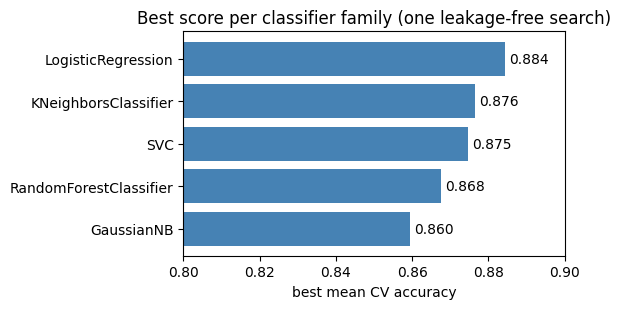

In [28]:
import matplotlib.pyplot as plt

results = pd.DataFrame(multi_search.cv_results_)

# The estimator object lives in the "param_clf" column; its class name labels the family.
results["family"] = results["param_clf"].apply(lambda est: type(est).__name__)

# Best mean CV score achieved by each family.
best_per_family = results.groupby("family")["mean_test_score"].max().sort_values()

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.barh(best_per_family.index, best_per_family.values, color="steelblue")
ax.set_xlim(0.80, 0.90)
ax.set_xlabel("best mean CV accuracy")
ax.set_title("Best score per classifier family (one leakage-free search)")
for y_pos, value in enumerate(best_per_family.values):
    ax.text(value + 0.001, y_pos, f"{value:.3f}", va="center")
plt.tight_layout()
plt.show()

## 7c. Head-to-head with `cross_val_score`

The bar chart used each family's tuned best. For a cleaner apples-to-apples picture we can run `cross_val_score` on a fresh pipeline per family with sensible defaults, all on the **same five folds**. Reporting **mean ± std** is the honest way to compare: a family that wins by less than the other's standard deviation has not really won. Because each pipeline re-fits its own preprocessing on every fold, this comparison stays leakage-free.

In [ ]:
from sklearn.model_selection import StratifiedKFold

# Identical folds for every family -> a fair comparison.
folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

candidates = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "SVC": SVC(random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(random_state=RANDOM_STATE),
}

rows = []
for name, estimator in candidates.items():
    family_pipe = Pipeline([("pre", preprocess), ("clf", estimator)])
    scores = cross_val_score(family_pipe, X_train, y_train, cv=folds)
    rows.append({"family": name, "mean_cv_accuracy": scores.mean(), "std": scores.std()})

head_to_head = pd.DataFrame(rows).set_index("family").sort_values("mean_cv_accuracy", ascending=False)
head_to_head.round(3)

,mean_cv_accuracy,std
family,,
LogisticRegression,0.879,0.018
SVC,0.876,0.020
RandomForest,0.871,0.019


## 7d. Predicting on brand-new raw patients

This is the payoff of pipelines. The winning pipeline (`multi_search.best_estimator_`) already contains the scaler, the one-hot encoder, and the classifier. So to score a **new patient** we hand it the *raw* values — unscaled numbers and integer-coded categories, exactly as they appear in the original CSV — and the pipeline applies every preprocessing step automatically before predicting.

No manual scaling, no manual encoding, no chance of forgetting a step or applying a stale scaler. We build a small DataFrame of three made-up patients using the **original raw columns** and call `.predict()`.

In [30]:
best_pipeline = multi_search.best_estimator_   # already refit on all of X_train

# Three brand-new patients, raw values in the ORIGINAL columns (same names/order as X).
new_patients = pd.DataFrame([
    {"Age": 41, "Sex": 0, "Chest pain type": 2, "BP": 120, "Cholesterol": 198,
     "FBS over 120": 0, "EKG results": 0, "Max HR": 168, "Exercise angina": 0,
     "ST depression": 0.0, "Slope of ST": 1, "Number of vessels fluro": 0, "Thallium": 3},
    {"Age": 67, "Sex": 1, "Chest pain type": 4, "BP": 160, "Cholesterol": 286,
     "FBS over 120": 0, "EKG results": 2, "Max HR": 108, "Exercise angina": 1,
     "ST depression": 1.5, "Slope of ST": 2, "Number of vessels fluro": 3, "Thallium": 7},
    {"Age": 55, "Sex": 1, "Chest pain type": 3, "BP": 132, "Cholesterol": 230,
     "FBS over 120": 0, "EKG results": 0, "Max HR": 143, "Exercise angina": 0,
     "ST depression": 0.6, "Slope of ST": 2, "Number of vessels fluro": 1, "Thallium": 3},
])[X.columns]   # ensure exact column order

# .predict() runs scaling + one-hot encoding + the classifier in one shot, on RAW input.
predicted_class = best_pipeline.predict(new_patients)
predicted_proba = best_pipeline.predict_proba(new_patients)[:, 1]

new_patients_out = new_patients[["Age", "Sex", "BP", "Cholesterol", "Max HR"]].copy()
new_patients_out["pred (1=disease)"] = predicted_class
new_patients_out["P(disease)"] = predicted_proba.round(3)
new_patients_out

,Age,Sex,BP,Cholesterol,Max HR,pred (1=disease),P(disease)
0,41,0,120,198,168,0,0.004
1,67,1,160,286,108,1,1.000
2,55,1,132,230,143,0,0.306


## 8. Inspecting inside a fitted pipeline

A pipeline hides its intermediate state behind one object. To reach a specific step, use `.named_steps[...]` (or `.named_steps.<name>`). This is how you pull out, say, the fitted classifier's coefficients or the encoder's learned categories.

In [35]:
fitted_pre = pipe.named_steps["pre"]            # the ColumnTransformer
fitted_clf = pipe.named_steps["clf"]            # the LogisticRegression

feature_names = fitted_pre.get_feature_names_out()
print("number of features the classifier actually sees:", len(feature_names))
print("first 6 feature names:", list(feature_names[:6]))


number of features the classifier actually sees: 28
first 6 feature names: ['num__Age', 'num__BP', 'num__Cholesterol', 'num__Max HR', 'num__ST depression', 'cat__Sex_0']


### Seeing the engineered feature names

Back in §3 the column count jumped from **13 raw -> 28 engineered**. `get_feature_names_out()` tells us exactly what those 28 columns *are*: the `num__` prefix marks the five rescaled numeric columns; every `cat__<col>_<value>` is one one-hot indicator. This is the precise list of inputs the classifier learns a coefficient for — handy for explaining a model or matching a coefficient back to a real-world feature.

In [ ]:
# Pull the full list of engineered feature names off the fitted ColumnTransformer.
engineered = pipe.named_steps["pre"].get_feature_names_out()

numeric_out = [f for f in engineered if f.startswith("num__")]
onehot_out = [f for f in engineered if f.startswith("cat__")]

print(f"{len(engineered)} engineered features = {len(numeric_out)} numeric + {len(onehot_out)} one-hot")
print("\nnumeric features:", numeric_ou
folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

candidates = {t)
print("\nfirst 8 one-hot features:", onehot_out[:8])

28 engineered features = 5 numeric + 23 one-hot

numeric features: ['num__Age', 'num__BP', 'num__Cholesterol', 'num__Max HR', 'num__ST depression']

first 8 one-hot features: ['cat__Sex_0', 'cat__Sex_1', 'cat__Chest pain type_1', 'cat__Chest pain type_2', 'cat__Chest pain type_3', 'cat__Chest pain type_4', 'cat__FBS over 120_0', 'cat__FBS over 120_1']


## Pitfalls / when NOT to

- **Malformed `step__param` keys (the #1 error).** The text before `__` must match a step name *exactly*. `"classifier__C"` when your step is named `"clf"`, or `"clf_C"` with a single underscore, both raise `ValueError: Invalid parameter`. The cell below triggers it on purpose so you recognise the message.
- **Unseen categories at predict time.** If a category appears in production that was absent during fit, a plain `OneHotEncoder` crashes. We use `handle_unknown="ignore"` so it emits an all-zeros row instead — essential for any model that will see live data.
- **Pipelines hide intermediate state.** You cannot index a pipeline like a list of fitted objects; reach inside with `pipe.named_steps["clf"]` (or `pipe[-1]`) to inspect coefficients, encoders, or scalers.
- **The leakage trap returns the moment you scale by hand.** If you ever call `StandardScaler().fit_transform(X)` *before* `train_test_split`, you are back to §2's bug — no pipeline can save you from preprocessing you did outside it. Keep every learned transformer inside the pipeline.
- **When a pipeline is overkill.** For a quick, one-off look at fully numeric data with no learned preprocessing, a bare estimator is fine. Reach for a pipeline the moment you have *any* fit-from-data step (scaling, encoding, imputation) plus cross-validation or a grid search.

In [ ]:
# Demonstrate the #1 pipeline error: a step name that does not exist.
try:print("classifier coefficient count:", fitted_clf.coef_.shape[1])
    bad = GridSearchCV(pipe, {"classifier__C": [1]}, cv=5)  # step is named "clf", not "classifier"
    bad.fit(X_train, y_train)
except ValueError as e:
    print("ValueError (as expected):")
    print(str(e)[:160], "...")

ValueError (as expected):
Invalid parameter 'classifier' for estimator Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                 ...


## Recap

- Fitting any **learned transformer** (scaler, encoder, imputer) on the full data before splitting **leaks** test information into training.
- A **`Pipeline`** bundles preprocessing + model so `.fit()` learns the preprocessing on training data only, and `.predict()` merely applies it.
- Under **cross-validation** the pipeline re-fits its preprocessing on each fold's training portion — leakage-free by construction. *This is why pipelines exist.*
- **`GridSearchCV`** tunes steps by name with the `step__param` double-underscore syntax, and a **list of param dicts** lets one search compare several classifier families and crown a single `best_params_`.

Forward-pointer: in **lec_13c** we wrap exactly this kind of search in **MLflow** — logging every parameter, metric, and fitted model so runs are tracked, comparable in a UI, and reproducible long after the notebook closes.